### Goal
##### Hi so my goal here to predcit that product will get funding or not based on data of this shark tank. i will first do EDA to understand data and based on my project requirement i will make model with proper data preprocessing to predcit that with data that user can give in my project. and also will perform model evaluation and also hyperperameter tuning and all if i need. i will describe my each stage and mindset of my each decision if anyone want to learn or tell me if find any mistake.

In [239]:
# !pip install optuna

In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.feature_extraction.text import TfidfVectorizer
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , RobustScaler , OneHotEncoder
from sklearn.model_selection import train_test_split , StratifiedKFold , cross_validate
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, log_loss, classification_report, roc_curve, confusion_matrix, PrecisionRecallDisplay
import optuna

In [241]:
import kagglehub
path = kagglehub.dataset_download("thirumani/shark-tank-us-dataset")

Using Colab cache for faster access to the 'shark-tank-us-dataset' dataset.


In [242]:
csv_path = os.path.join(path, "Shark Tank US dataset.csv")
df = pd.read_csv(csv_path)

### Data Sanity Check And Validation

In [243]:
df.sample(1)

,Season Number,Startup Name,Episode Number,Pitch Number,Season Start,Season End,Original Air Date,Industry,Business Description,Company Website,...,Guest Investment Amount,Guest Investment Equity,Guest Name,Barbara Corcoran Present,Mark Cuban Present,Lori Greiner Present,Robert Herjavec Present,Daymond John Present,Kevin O Leary Present,Guest Present
139,3,Bark'em'sToGo,10,140,20-Jan-12,18-May-12,23-Mar-12,Pet Products,Bark‚Äôem‚Äôs To Go - Pet Products,http://www.barkems.com/,...,NaN,NaN,NaN,1.0,1.0,0.0,1.0,1.0,1.0,NaN


In [244]:
df.shape

(1485, 53)

In [245]:
df.duplicated().sum()

np.int64(0)

In [246]:
print(df.isnull().mean() * 100)

Season Number                          0.000000
Startup Name                           0.000000
Episode Number                         0.000000
Pitch Number                           0.000000
Season Start                           0.000000
Season End                             2.962963
Original Air Date                      0.000000
Industry                               0.000000
Business Description                   0.000000
Company Website                       35.286195
Pitchers Gender                        0.606061
Pitchers Average Age                  63.164983
Pitchers City                         44.915825
Pitchers State                        36.296296
Entrepreneur Names                    33.602694
Multiple Entrepreneurs                28.888889
US Viewership                          0.808081
Original Ask Amount                    0.269360
Original Offered Equity                0.269360
Valuation Requested                    0.269360
Got Deal                               0

### Alright so based on this columns and mising value checking i make this decisions
##### 1. we have only 1485 rows with 53 columns and my target is  "Got Deal"   for my project
##### 2. now first thing we  dont have too much data here so we cant use model with high varience here so we will use some basemodel with preprocess first.
##### 3. there is lot of colums that are basicly cause **"data leakage"** because some colums are cleary possible after knowing that they got deal so we have to remove those first like Total Deal Amount, Total Deal Equity, Deal Valuation, Number of Sharks in Deal, Investment Amount Per Shark, Equity Per Shark
##### 4. now there is some columns that should not put any value in predcit deal bit if we add it then it will make bias where we dont need like Gender so we will drop Pitchers Gender, Pitchers Average Age, Entrepreneur Names, Pitchers City, Pitchers State.
##### 5. now will dop columsn that are missing so much and also like metadata and not applicable Season Number, Episode Number, Pitch Number, Season Start, Season End, Original Air Date, US Viewership this add no value
##### 6. now will drop Rows that have missing value in target col because i dont want to add noise data.


In [247]:
columns_to_keep = ["Industry","Multiple Entrepreneurs","Business Description","Original Ask Amount","Original Offered Equity","Valuation Requested","Got Deal"]
df = df[columns_to_keep].copy()

In [248]:
df = df.dropna(subset=["Got Deal"])

In [249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1481 entries, 0 to 1480
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Industry                 1481 non-null   object 
 1   Multiple Entrepreneurs   1054 non-null   float64
 2   Business Description     1481 non-null   object 
 3   Original Ask Amount      1481 non-null   float64
 4   Original Offered Equity  1481 non-null   float64
 5   Valuation Requested      1481 non-null   float64
 6   Got Deal                 1481 non-null   float64
dtypes: float64(5), object(2)
memory usage: 92.6+ KB


### what I select for my problem
##### so i drop lot of colums because for what problem i am making model it add leakage, wrong bias, mostly missing, metadata or something like this so i keep only this much data now lets go for EDA

### EDA

#### Target Analysis

In [250]:
TARGET = "Got Deal"

In [251]:
df[TARGET] = df[TARGET].astype(int)

In [252]:
print("Unique Value :" , df[TARGET].unique())
print("Value Count : " , df[TARGET].value_counts())

Unique Value : [1 0]
Value Count :  Got Deal
1    914
0    567
Name: count, dtype: int64


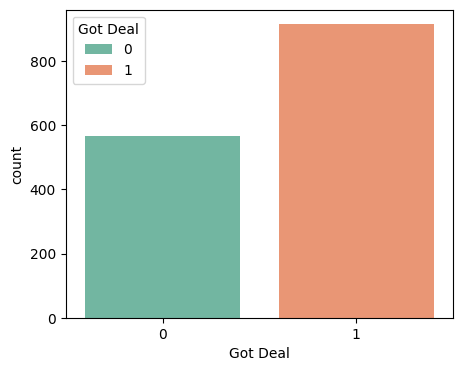

In [253]:
plt.figure(figsize=(5,4))
sns.countplot(data =df , x = TARGET , palette='Set2' , hue = TARGET)
plt.show()

##### Target have normal Imbelance so will put class weight. i was expecting that mostly people dont get deals but wow this is new to me

#### Missing Value Investigation


In [254]:
df.isnull().mean() * 100

,0
Industry,0.00000
Multiple Entrepreneurs,28.83187
Business Description,0.00000
Original Ask Amount,0.00000
Original Offered Equity,0.00000
Valuation Requested,0.00000
Got Deal,0.00000


In [255]:
df['Multiple Entrepreneurs'].unique()

array([ 0.,  1., nan])

<Axes: ylabel='count'>

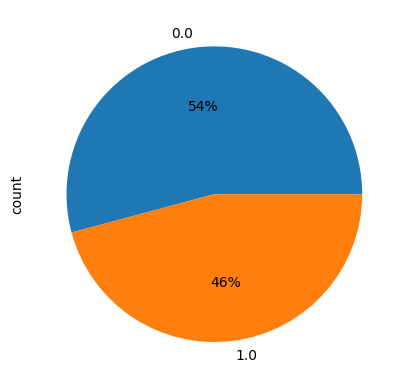

In [256]:
df['Multiple Entrepreneurs'].value_counts().plot.pie(autopct='%.0f%%')

##### very balanced i see still 0 is 54% so lets just try with Simple Imputation based on fequency for now

#### Outliers Check

In [257]:
df.head()

,Industry,Multiple Entrepreneurs,Business Description,Original Ask Amount,Original Offered Equity,Valuation Requested,Got Deal
0,Health/Wellness,0.0,Ava The Elephant - Baby and Child Care,50000.0,15.0,333333.0,1
1,Food and Beverage,0.0,Mr. Tod's Pie Factory - Specialty Food,460000.0,10.0,4600000.0,1
2,Business Services,0.0,Wispots - Consumer Services,1200000.0,10.0,12000000.0,0
3,Lifestyle/Home,0.0,College Foxes Packing Boxes - Consumer Services,250000.0,25.0,1000000.0,0
4,Technology/Software,0.0,Ionic Ear - Novelties,1000000.0,15.0,6666667.0,0


In [258]:
for col in df.columns:
  print("Unique Value for",col ,":" , df[col].nunique())

Unique Value for Industry : 16
Unique Value for Multiple Entrepreneurs : 2
Unique Value for Business Description : 1478
Unique Value for Original Ask Amount : 79
Unique Value for Original Offered Equity : 47
Unique Value for Valuation Requested : 180
Unique Value for Got Deal : 2


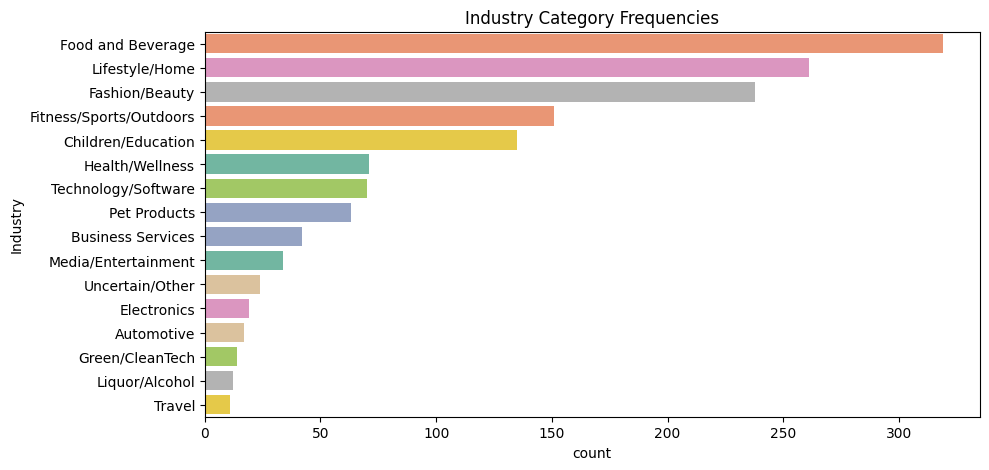

In [259]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Industry', order=df['Industry'].value_counts().index, palette='Set2' , hue = 'Industry')
plt.title('Industry Category Frequencies')
plt.show()

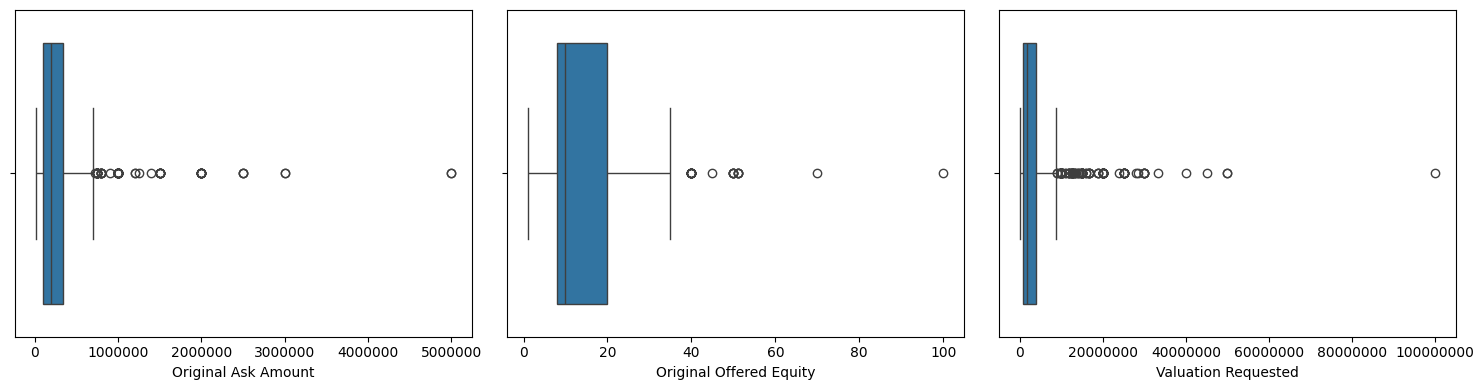

In [260]:
col_to_check = ['Original Ask Amount','Original Offered Equity','Valuation Requested']

plt.figure(figsize = (15 , 4))
for i,col in enumerate(col_to_check):
  plt.subplot(1,3,i+1)
  sns.boxplot(data = df , x=col)
  plt.xlabel(col)
  plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()


In [261]:
with pd.option_context('display.max_columns', None, 'display.width', 1000):
  for col in col_to_check:
      print(f"\nTop 10 Highest Outliers for: {col}")

      z = zscore(df[col])
      outliers = df[z > 3]
      top_10_outliers = outliers.sort_values(by=col, ascending=False).head(10)
      print(top_10_outliers)


Top 10 Highest Outliers for: Original Ask Amount
                     Industry  Multiple Entrepreneurs                             Business Description  Original Ask Amount  Original Offered Equity  Valuation Requested  Got Deal
254       Media/Entertainment                     1.0                       Track Days - Entertainment            5000000.0                     34.0           14705882.0         0
483                    Travel                     1.0        AirCar Zero Pollution Motors - Automotive            5000000.0                     50.0           10000000.0         1
489           Health/Wellness                     0.0                        SynDaver Labs - Education            3000000.0                     10.0           30000000.0         1
151   Fitness/Sports/Outdoors                     0.0                     Skyride - Outdoor Recreation            3000000.0                     20.0           15000000.0         0
562            Fashion/Beauty                     

##### Alright so there is outliers and those outliers are superhight and rare like there is one person who give 100% of his componie thats very rare.

#### Data Destribution Checking

In [262]:
for col in col_to_check:
  print(col , ":" , df[col].skew())

Original Ask Amount : 5.999277178106162
Original Offered Equity : 2.1613587501959426
Valuation Requested : 5.6677104222839825


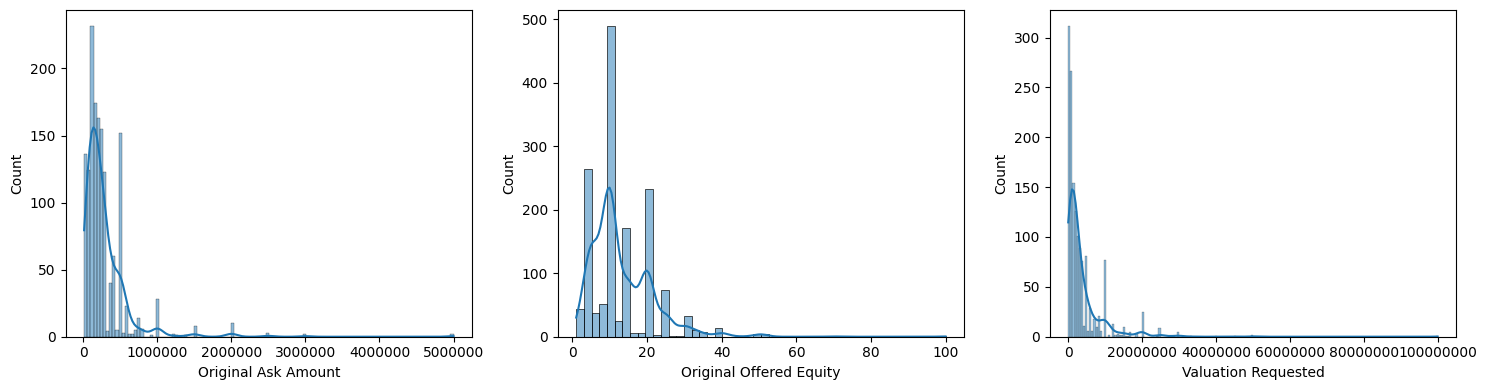

In [263]:
plt.figure(figsize = (15 , 4))
for i,col in enumerate(col_to_check):
  plt.subplot(1,3,i+1)
  sns.histplot(data = df , x=col , kde = True)
  plt.xlabel(col)
  plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

##### so data is so much slew so i guess if we are not using treebased model then we have to take care of this because outliers are much as well

#### Business Description col analysis

In [264]:
df['desc_char_len'] = df['Business Description'].astype(str).apply(len)
df['desc_word_count'] = df['Business Description'].astype(str).apply(lambda x: len(x.split()))

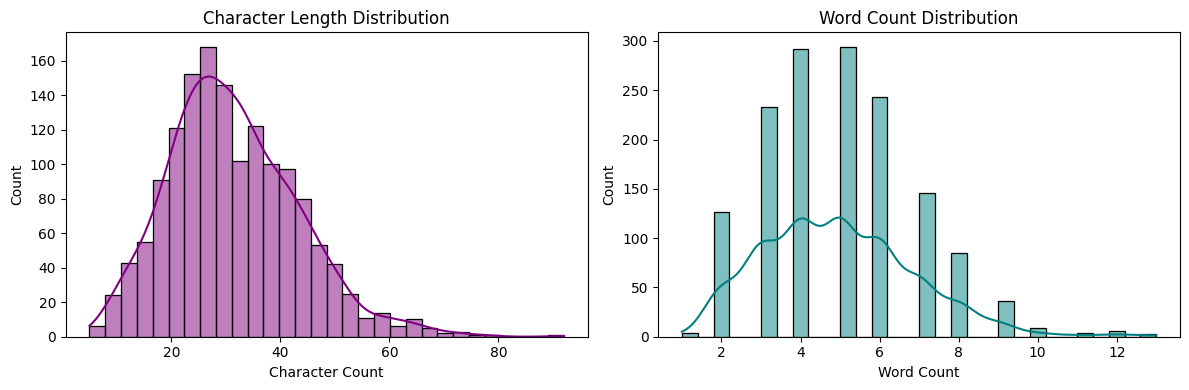

In [265]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['desc_char_len'], bins=30, kde=True, color='purple')
plt.title('Character Length Distribution')
plt.xlabel('Character Count')

plt.subplot(1, 2, 2)
sns.histplot(df['desc_word_count'], bins=30, kde=True, color='teal')
plt.title('Word Count Distribution')
plt.xlabel('Word Count')

plt.tight_layout()

In [266]:
placeholders = ['n/a', 'none', 'null', 'nan', 'unknown', '']
df_clean_text = df['Business Description'].astype(str).str.strip().str.lower()

empty_count = df_clean_text.isin(placeholders).sum()
short_count = (df['desc_word_count'] < 3).sum()
duplicate_count = df['Business Description'].duplicated().sum()

print(f"Empty/Placeholder Rows: {empty_count}")
print(f"Very Short Rows (<3 words): {short_count}")
print(f"Duplicate Descriptions: {duplicate_count}")

Empty/Placeholder Rows: 0
Very Short Rows (<3 words): 130
Duplicate Descriptions: 3


In [267]:
if duplicate_count > 0:
    print("\nSample Duplicates:")
    print(df[df['Business Description'].duplicated(keep=False)][['Business Description', 'Got Deal']].head(6))


Sample Duplicates:
                    Business Description  Got Deal
67    Copa di Vino - Alcoholic Beverages         0
142   Copa di Vino - Alcoholic Beverages         0
242   Echo Valley Meats - Specialty Food         0
463   Echo Valley Meats - Specialty Food         1
1358                        Protein Bars         1
1447                        Protein Bars         1


##### 3 repeats is looking ok  but about that too small description i dont think its good in understanding in decode so will see what we can do later

#### Feature - Target Realtionship

In [268]:
df.head()

,Industry,Multiple Entrepreneurs,Business Description,Original Ask Amount,Original Offered Equity,Valuation Requested,Got Deal,desc_char_len,desc_word_count
0,Health/Wellness,0.0,Ava The Elephant - Baby and Child Care,50000.0,15.0,333333.0,1,38,8
1,Food and Beverage,0.0,Mr. Tod's Pie Factory - Specialty Food,460000.0,10.0,4600000.0,1,38,7
2,Business Services,0.0,Wispots - Consumer Services,1200000.0,10.0,12000000.0,0,27,4
3,Lifestyle/Home,0.0,College Foxes Packing Boxes - Consumer Services,250000.0,25.0,1000000.0,0,47,7
4,Technology/Software,0.0,Ionic Ear - Novelties,1000000.0,15.0,6666667.0,0,21,4


<Axes: xlabel='Multiple Entrepreneurs', ylabel='Got Deal'>

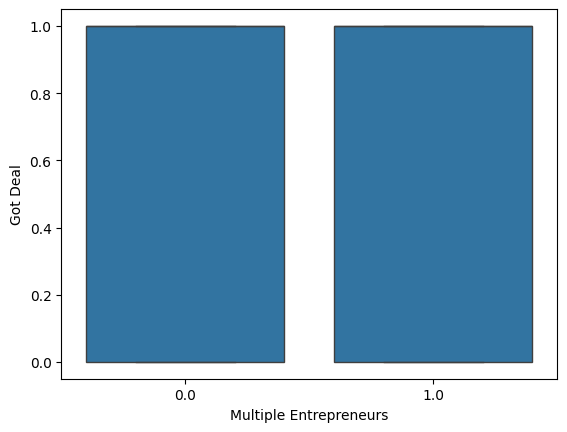

In [269]:
sns.boxplot(data = df , x = 'Multiple Entrepreneurs' , y = TARGET)

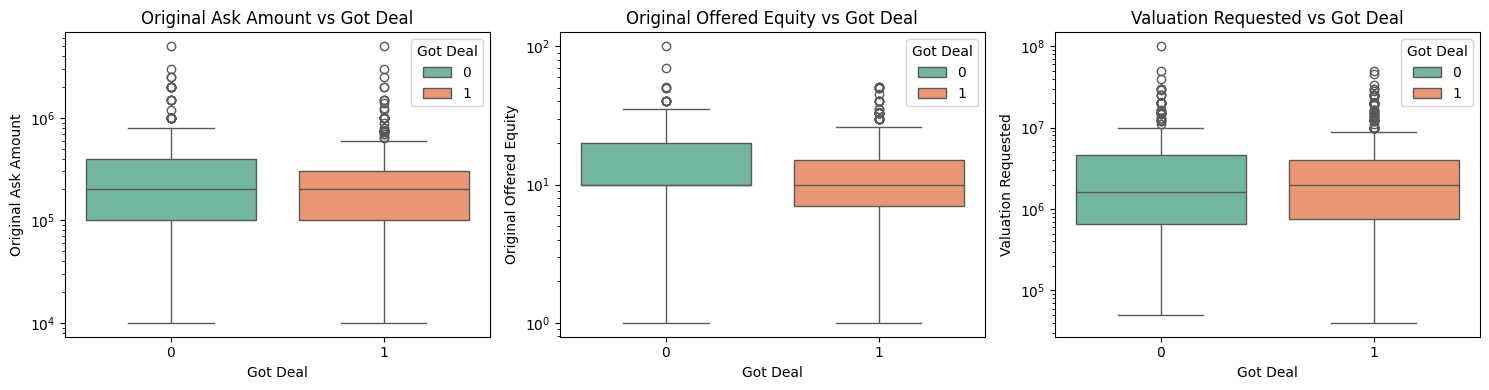

In [270]:
plt.figure(figsize=(15, 4))
for i, col in enumerate(col_to_check):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, x=TARGET, y=col, palette='Set2', hue=TARGET)
    plt.yscale('log')
    plt.title(f"{col} vs {TARGET}")

plt.tight_layout()
plt.show()

#### Correlation (feature to feature)

<Axes: >

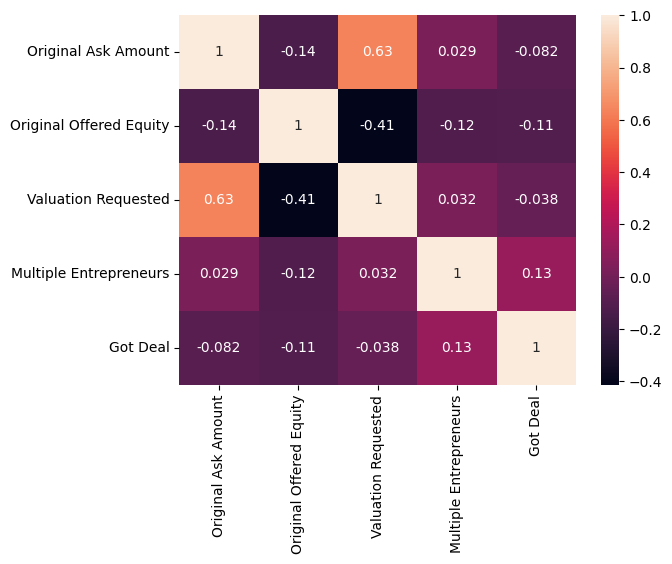

In [271]:
numeric_cols = ['Original Ask Amount', 'Original Offered Equity', 'Valuation Requested', 'Multiple Entrepreneurs', 'Got Deal']

sns.heatmap(df[numeric_cols].corr()  , annot = True)

##### alright so i check correlation non of the feature is highly correlatedand linearly independent i mean i dont think any of those will cause multicorr or data leakage so np i guess

In [272]:
implied = df['Original Ask Amount'] / (df['Original Offered Equity'] / 100)
(implied - df['Valuation Requested']).abs().describe()

,0
count,1.481000e+03
mean,5.856670e+04
std,1.590345e+06
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,4.800000e+07


##### alright so i was expecting so basicly valuation requested is non linearly connected to ask amount and offered equity so we have to remove it because it will add 0% unique new information

### Data Preprocessing & preparing

##### Based on EDA will perform operations on data

#### Drop what we dont need

In [273]:
df = df.drop(columns = ['Valuation Requested','desc_char_len', 'desc_word_count'])
df.columns

Index(['Industry', 'Multiple Entrepreneurs', 'Business Description',
       'Original Ask Amount', 'Original Offered Equity', 'Got Deal'],
      dtype='object')

#### Mapping less frequent value

In [274]:
industry_map = {
    'Food and Beverage': 'Food & Beverage',
    'Liquor/Alcohol': 'Food & Beverage',
    'Lifestyle/Home': 'Home & Lifestyle',
    'Pet Products': 'Home & Lifestyle',
    'Fashion/Beauty': 'Fashion & Beauty',
    'Fitness/Sports/Outdoors': 'Health & Fitness',
    'Health/Wellness': 'Health & Fitness',
    'Children/Education': 'Kids & Education',
    'Technology/Software': 'Technology & Engineering',
    'Electronics': 'Technology & Engineering',
    'Green/CleanTech': 'Technology & Engineering',
    'Automotive': 'Technology & Engineering',
    'Business Services': 'Media & Business Services',
    'Media/Entertainment': 'Media & Business Services',
    'Travel': 'Media & Business Services',
    'Uncertain/Other': 'Other'
}

df['Industry'] = df['Industry'].map(industry_map)

In [275]:
df['Pitch'] = df['Industry'] + " pitch: " + df['Business Description']
df = df.drop(columns=['Business Description'])

##### i created this column this is what i am taking from user in my project and also business description was too small in data so we ant get proper meaning with embeddings.

In [276]:
X_raw = df.drop(columns=[TARGET])
y = df[TARGET].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

In [277]:
X_train_raw = X_train_raw.reset_index(drop=True)
X_test_raw = X_test_raw.reset_index(drop=True)

In [278]:
num_cols = ['Original Ask Amount', 'Original Offered Equity']

#### Missing value Imputation

In [279]:
imputer = SimpleImputer(strategy='most_frequent')

df_train_imp = pd.DataFrame(imputer.fit_transform(X_train_raw[['Multiple Entrepreneurs']]), columns=['Multiple Entrepreneurs'])
df_test_imp = pd.DataFrame(imputer.transform(X_test_raw[['Multiple Entrepreneurs']]), columns=['Multiple Entrepreneurs'])

In [280]:
df_train_imp.isnull().sum()

,0
Multiple Entrepreneurs,0


#### Encoding

In [281]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
cat_cols = [f"cat_{cat}" for cat in encoder.fit(X_train_raw[['Industry']]).categories_[0]]

df_train_cat = pd.DataFrame(encoder.transform(X_train_raw[['Industry']]), columns=cat_cols)
df_test_cat = pd.DataFrame(encoder.transform(X_test_raw[['Industry']]), columns=cat_cols)

In [282]:
df_train_cat.sample(1)

,cat_Fashion & Beauty,cat_Food & Beverage,cat_Health & Fitness,cat_Home & Lifestyle,cat_Kids & Education,cat_Media & Business Services,cat_Other,cat_Technology & Engineering
1064,1,0,0,0,0,0,0,0


#### Transformation

In [283]:
train_log = np.log1p(X_train_raw[num_cols])
test_log = np.log1p(X_test_raw[num_cols])

#### Scaling

##### i am choosing robuse scaler because we have some value super extreme like in Original Amount ask mostly value is between 25k to 200k butsome value is super extreme like 5 million + so because if MinMax scaler will sqize down from 0 to  0.005 something also standerd scaler is mean based so we will use robust scaler that is median based so more reliable on extreme outliers like this

In [284]:
scaler = RobustScaler()

df_train_num = pd.DataFrame(scaler.fit_transform(train_log), columns=num_cols)
df_test_num = pd.DataFrame(scaler.transform(test_log), columns=num_cols)

In [285]:
df_train_num.sample(2)

,Original Ask Amount,Original Offered Equity
610,0.203114,0.763164
651,0.834046,-0.715375


#### Embedding Model

In [286]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [287]:
train_emb = embedder.encode(X_train_raw['Pitch'].tolist(), show_progress_bar=True)
test_emb = embedder.encode(X_test_raw['Pitch'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

##### this many dimensions will cause Curse of Dimensionality if we use SVC type of model and also cause overfit if use boosing based models o lets do PCA to stay in safe side

In [288]:
pca = PCA(n_components=20, random_state=42)
pca_cols = [f"pca_emb_{i}" for i in range(20)]

df_train_pca = pd.DataFrame(pca.fit_transform(train_emb), columns=pca_cols)
df_test_pca = pd.DataFrame(pca.transform(test_emb), columns=pca_cols)

### Data Preparation

In [289]:
X_train = pd.concat([df_train_imp, df_train_num, df_train_cat, df_train_pca], axis=1)
X_test = pd.concat([df_test_imp, df_test_num, df_test_cat, df_test_pca], axis=1)

In [290]:
X_train.shape

(1184, 31)

In [291]:
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

### Model Training

##### Alright so i try so many models with CV and finaly decide Logistc Regression because other models dont perfrom that well and i expected because of small data as well as missing information in pitch that as well that causse other model(xgb , random forest... etc high varienc models) to train more on noise then actual information anyways i will hyper tune it with optuna now

In [292]:
def objective(trial):
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])
    if solver == 'liblinear':
        penalty = trial.suggest_categorical('penalty_liblinear', ['l1', 'l2'])
    elif solver == 'saga':
        penalty = trial.suggest_categorical('penalty_saga', ['l1', 'l2', 'elasticnet'])
    else:
        penalty = 'l2'

    l1_ratio = None
    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)

    c_val = trial.suggest_float('C', 1e-4, 10.0, log=True)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])

    model = LogisticRegression(
        C=c_val,
        penalty=penalty,
        solver=solver,
        l1_ratio=l1_ratio,
        class_weight=class_weight,
        max_iter=2000,
        random_state=42
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    return scores['test_score'].mean()

study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=300, show_progress_bar=True)

print("Best Trial ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)

  0%|          | 0/300 [00:00<?, ?it/s]

Best Trial ROC-AUC: 0.610092017137027
Best Parameters: {'solver': 'lbfgs', 'C': 0.6563296409233873, 'class_weight': 'balanced'}


In [293]:
best_params = study.best_params.copy()
solver = best_params.get('solver')
penalty = best_params.get('penalty_liblinear') or best_params.get('penalty_saga') or 'l2'
l1_ratio = best_params.get('l1_ratio', None)

lr_model = LogisticRegression(
    C=best_params['C'],
    penalty=penalty,
    solver=solver,
    l1_ratio=l1_ratio,
    class_weight=best_params['class_weight'],
    max_iter=2000,
    random_state=42
)

In [294]:
lr_model.fit(X_train, y_train)

LogisticRegression(C=0.6563296409233873, class_weight='balanced', max_iter=2000,
                   random_state=42)

In [295]:
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]
y_pred = lr_model.predict(X_test)

In [296]:
test_auc = roc_auc_score(y_test, y_pred_proba)
test_logloss = log_loss(y_test, y_pred_proba)

print(f"--- Hold-Out Test Results ---")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"Test Log-Loss : {test_logloss:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- Hold-Out Test Results ---
Test ROC-AUC  : 0.5957
Test Log-Loss : 0.6846

Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.59      0.49       114
           1       0.65      0.49      0.56       183

    accuracy                           0.53       297
   macro avg       0.54      0.54      0.52       297
weighted avg       0.56      0.53      0.53       297



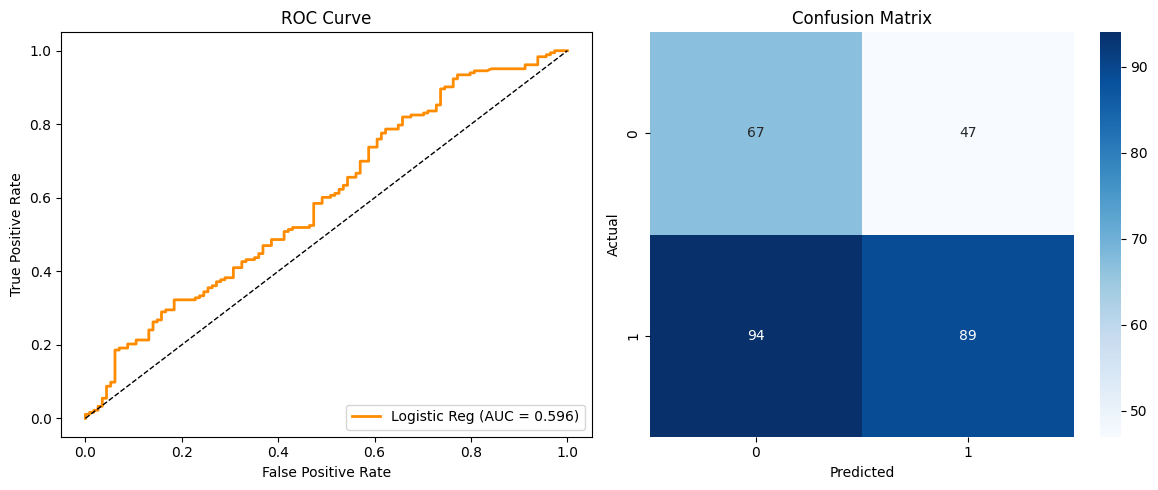

In [299]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax[0].plot(fpr, tpr, label=f'Logistic Reg (AUC = {test_auc:.3f})', color='darkorange', lw=2)
ax[0].plot([0, 1], [0, 1], 'k--', lw=1)
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve')
ax[0].legend(loc='lower right')

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

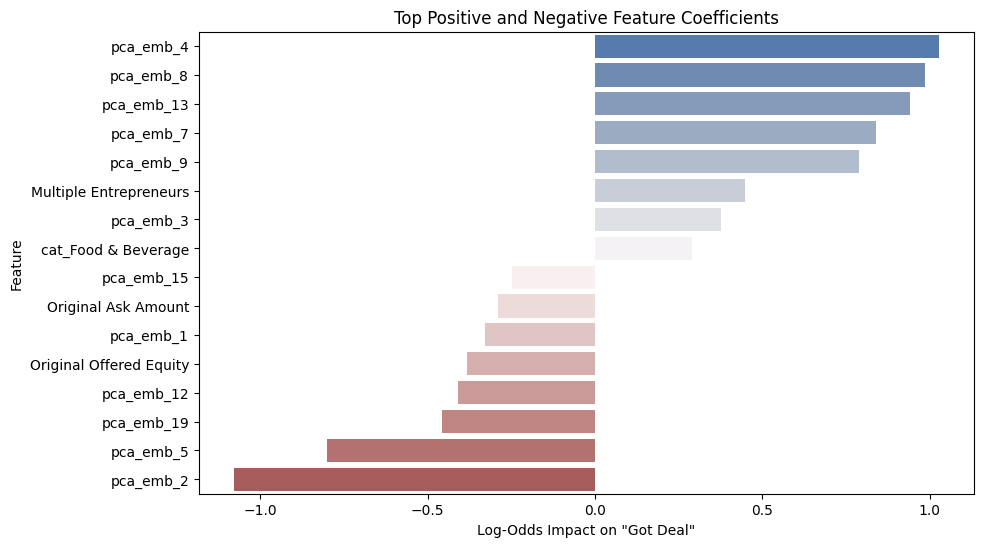

In [302]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
top_bottom_features = pd.concat([coefficients.head(8), coefficients.tail(8)])
sns.barplot(data=top_bottom_features, x='Coefficient', y='Feature', palette='vlag' , hue = "Feature")
plt.title('Top Positive and Negative Feature Coefficients')
plt.xlabel('Log-Odds Impact on "Got Deal"')
plt.show()

### Final Decision

#### so model i made follow best possible pipeline and work of 1.5 days of different perameter , trial and error loop and everything but resultwe get is ~60% AUC-ROC that means its close to random guess so i think i wonr use this in my project
#### Why got this bad result?
##### because in shark tank only original invenstment ask , industry , offerd equery and shord business describtion dont decide that they will make offer and investment or not. invest mater other lot of things like their entire dynamic discussion as well as problme they are solving , impression , presentation other lot of fectore and that much data we dont have and also we cant ask that in our project as well so i cant se it